# 1. Import Libraries

In [1]:
# Numerical and Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


# Load the data file

In [2]:
df = pd.read_csv("5x127x127_training_with_morphology.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (204573, 84)


# 3. EDA

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 204573
Number of columns: 84


Number of duplicate rows: 0
count    204573.000000
mean          0.595007
std           0.572976
min           0.010100
25%           0.212570
50%           0.488950
75%           0.694360
max           3.997880
Name: specz_redshift, dtype: float64


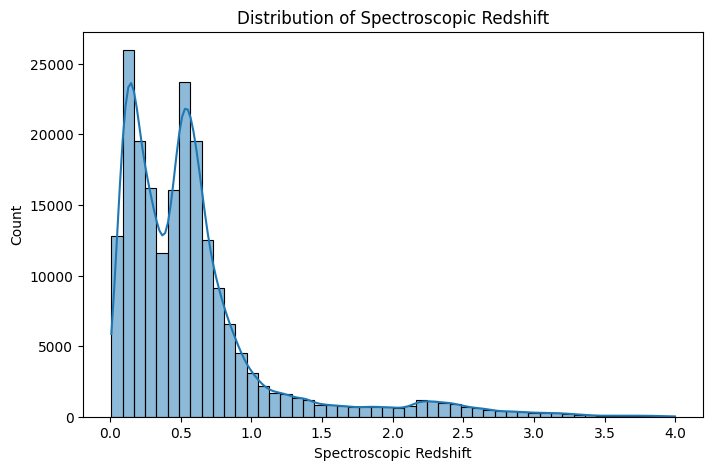

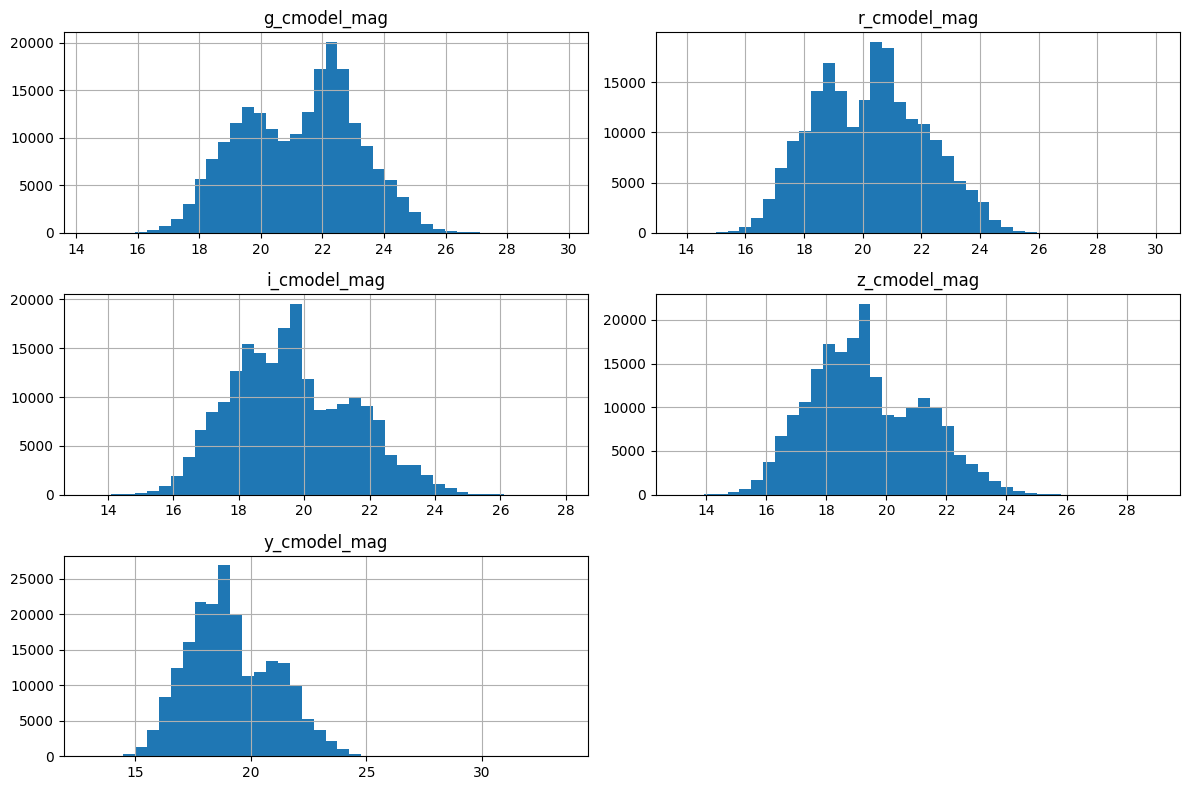

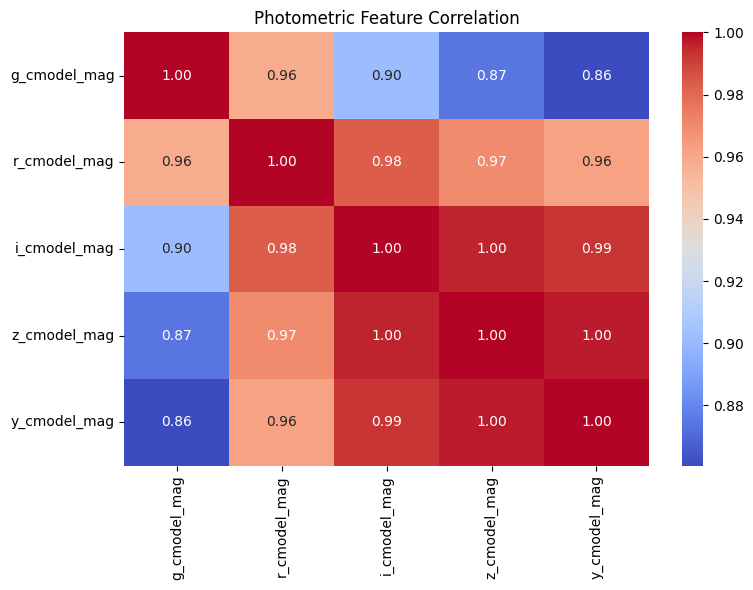

In [4]:

missing_values = df.isnull().sum()
missing_values[missing_values > 0]

print("Number of duplicate rows:", df.duplicated().sum())

print(df["specz_redshift"].describe())

plt.figure(figsize=(8, 5))

sns.histplot(df["specz_redshift"], bins=50, kde=True)

plt.xlabel("Spectroscopic Redshift")
plt.ylabel("Count")
plt.title("Distribution of Spectroscopic Redshift")

plt.show()

photometric_features = [
    "g_cmodel_mag",
    "r_cmodel_mag",
    "i_cmodel_mag",
    "z_cmodel_mag",
    "y_cmodel_mag"
]

df[photometric_features].describe()

df[photometric_features].hist(figsize=(12, 8), bins=40)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[photometric_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Photometric Feature Correlation")
plt.tight_layout()
plt.show()

# 4. Feature & Target Definition

In [5]:
target = "specz_redshift"

X = df[photometric_features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (204573, 5)
y shape: (204573,)


In [6]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())
print("Infinite values in X:", np.isinf(X).sum().sum())
print("Infinite values in y:", np.isinf(y).sum())


Missing values in X: 0
Missing values in y: 0
Infinite values in X: 0
Infinite values in y: 0


# 5. Train / Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)



X_train: (163658, 5)
X_test : (40915, 5)


In [8]:
print("Training target statistics:")
print(y_train.describe())

print("\nTesting target statistics:")
print(y_test.describe())

Training target statistics:
count    163658.000000
mean          0.594840
std           0.573359
min           0.010100
25%           0.211853
50%           0.488910
75%           0.694282
max           3.997880
Name: specz_redshift, dtype: float64

Testing target statistics:
count    40915.000000
mean         0.595677
std          0.571450
min          0.010150
25%          0.215505
50%          0.489210
75%          0.694772
max          3.974660
Name: specz_redshift, dtype: float64


# 6. Model Building
## 6.1 Linear Regression

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)
lr_preds_train = lr_model.predict(X_train_scaled)

lr_r2_testing = r2_score(y_test, lr_preds)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

print("Linear Regression")
print("-----------------")
print(f"Accuracy of Training: {lr_r2_training}")
print(f"Accuracy of Testing: {lr_r2_testing}")
print(f"MAE: {lr_mae}")
print(f"RMSE: {lr_rmse}")

Linear Regression
-----------------
Accuracy of Training: 0.3418549155561915
Accuracy of Testing: 0.34293654186979106
MAE: 0.28916276712899625
RMSE: 0.4632083904930817


## 6.2 Random Forest

In [10]:
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_preds_train = rf_model.predict(X_train)

rf_r2_testing = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_train)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print("Random Forest (default)")
print("------------------------")
print(f"Accuracy of Training: {rf_r2_training}")
print(f"Accuracy of Testing: {rf_r2_testing}")
print(f"MAE: {rf_mae}")
print(f"RMSE: {rf_rmse}")


Random Forest (default)
------------------------
Accuracy of Training: 0.9610628369919868
Accuracy of Testing: 0.7309937789209129
MAE: 0.11853403099536813
RMSE: 0.2963834314380794


In [13]:
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

print("CV R² scores:", rf_cv_scores)
print("Mean CV R²:", rf_cv_scores.mean())
print("Std CV R²:", rf_cv_scores.std())

CV R² scores: [0.7149259  0.72954889 0.71473424 0.71213877 0.7219878 ]
Mean CV R²: 0.7186671186030542
Std CV R²: 0.0063485989876990315


In [14]:
# NOTE: reduce n_iter/cv/n_jobs below if this freezes your machine —
# it will still run, just search a smaller space (see Experiment 2 README for the trade-off)
rf_param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [1.0, 'sqrt']
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random.fit(X_train, y_train)

print("Best Parameters:", rf_random.best_params_)
print("Best CV R²:", rf_random.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/home/rupam/anaconda3/envs/dlenv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV R²: 0.7253198754920893


In [15]:
best_rf = rf_random.best_estimator_

rf_tuned_preds = best_rf.predict(X_test)
rf_tuned_preds_train = best_rf.predict(X_train)

rf_tuned_r2_testing = r2_score(y_test, rf_tuned_preds)
rf_tuned_r2_training = r2_score(y_train, rf_tuned_preds_train)
rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))

print("Random Forest (tuned)")
print("----------------------")
print(f"Accuracy of Training: {rf_tuned_r2_training}")
print(f"Accuracy of Testing: {rf_tuned_r2_testing}")
print(f"MAE: {rf_tuned_mae}")
print(f"RMSE: {rf_tuned_rmse}")

Random Forest (tuned)
----------------------
Accuracy of Training: 0.9367931917207404
Accuracy of Testing: 0.7355930408770925
MAE: 0.11879890335933439
RMSE: 0.2938388399331404


## 6.3 Gradient Boosting

In [16]:
gbr_model = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)
gbr_model.fit(X_train, y_train)

gbr_preds = gbr_model.predict(X_test)
gbr_preds_train = gbr_model.predict(X_train)

gbr_r2_testing = r2_score(y_test, gbr_preds)
gbr_r2_training = r2_score(y_train, gbr_preds_train)
gbr_mae = mean_absolute_error(y_test, gbr_preds)
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_preds))

print("Gradient Boosting (default)")
print("-----------------------------")
print(f"Accuracy of Training: {gbr_r2_training}")
print(f"Accuracy of Testing: {gbr_r2_testing}")
print(f"MAE: {gbr_mae}")
print(f"RMSE: {gbr_rmse}")

Gradient Boosting (default)
-----------------------------
Accuracy of Training: 0.615700730909706
Accuracy of Testing: 0.6152603136522774
MAE: 0.17670281862683165
RMSE: 0.35445103865999716


In [17]:
gbr_param_grid = {
    'n_estimators': [100, 150, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

gbr_random = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=gbr_param_grid,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gbr_random.fit(X_train, y_train)

print("Best Parameters:", gbr_random.best_params_)
print("Best CV R²:", gbr_random.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 5, 'learning_rate': 0.15}
Best CV R²: 0.6967177663304354


In [18]:
best_gbr = gbr_random.best_estimator_

gbr_tuned_preds = best_gbr.predict(X_test)
gbr_tuned_preds_train = best_gbr.predict(X_train)

gbr_tuned_r2_testing = r2_score(y_test, gbr_tuned_preds)
gbr_tuned_r2_training = r2_score(y_train, gbr_tuned_preds_train)
gbr_tuned_mae = mean_absolute_error(y_test, gbr_tuned_preds)
gbr_tuned_rmse = np.sqrt(mean_squared_error(y_test, gbr_tuned_preds))

print("Gradient Boosting (tuned)")
print("---------------------------")
print(f"Accuracy of Training: {gbr_tuned_r2_training}")
print(f"Accuracy of Testing: {gbr_tuned_r2_testing}")
print(f"MAE: {gbr_tuned_mae}")
print(f"RMSE: {gbr_tuned_rmse}")

Gradient Boosting (tuned)
---------------------------
Accuracy of Training: 0.7653529637797737
Accuracy of Testing: 0.7060693589490583
MAE: 0.13471873585651234
RMSE: 0.30980982821721104


# 7. Model Evaluation

In [19]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest (default)',
        'Random Forest (tuned)',
        'Gradient Boosting (default)',
        'Gradient Boosting (tuned)'
    ],
    'R2': [
        lr_r2_testing, rf_r2_testing, rf_tuned_r2_testing,
        gbr_r2_testing, gbr_tuned_r2_testing
    ],
    'Training R2': [
        lr_r2_training, rf_r2_training, rf_tuned_r2_training,
        gbr_r2_training, gbr_tuned_r2_training
    ],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae, gbr_mae, gbr_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse, gbr_rmse, gbr_tuned_rmse]
})

print(results)


                         Model        R2  Training R2       MAE      RMSE
0            Linear Regression  0.342937     0.341855  0.289163  0.463208
1      Random Forest (default)  0.730994     0.961063  0.118534  0.296383
2        Random Forest (tuned)  0.735593     0.936793  0.118799  0.293839
3  Gradient Boosting (default)  0.615260     0.615701  0.176703  0.354451
4    Gradient Boosting (tuned)  0.706069     0.765353  0.134719  0.309810


# 8. Analysis

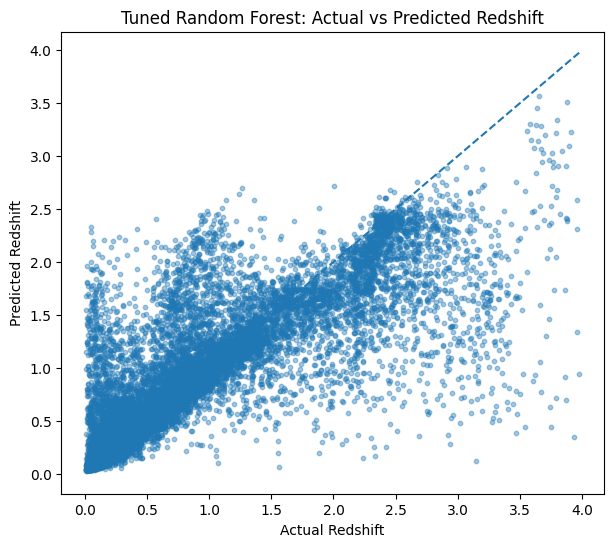

In [20]:
# Actual vs Predicted — best RF variant, swap in gbr_tuned_preds if GBR wins
plt.figure(figsize=(7, 6))
plt.scatter(y_test, rf_tuned_preds, alpha=0.4, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel("Actual Redshift")
plt.ylabel("Predicted Redshift")
plt.title("Tuned Random Forest: Actual vs Predicted Redshift")
plt.show()

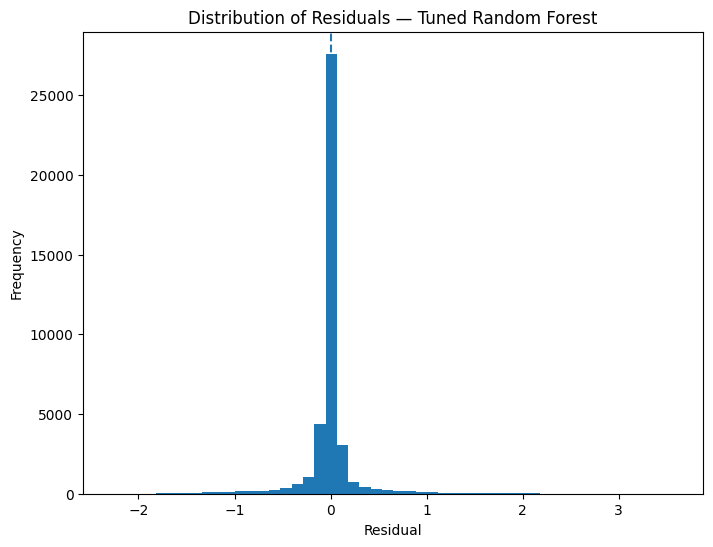

In [21]:
residuals = y_test - rf_tuned_preds

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=50)
plt.axvline(0, linestyle='--')
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals — Tuned Random Forest")
plt.show()

        Feature  Importance
0  g_cmodel_mag    0.253289
4  y_cmodel_mag    0.243850
3  z_cmodel_mag    0.184901
2  i_cmodel_mag    0.168876
1  r_cmodel_mag    0.149084


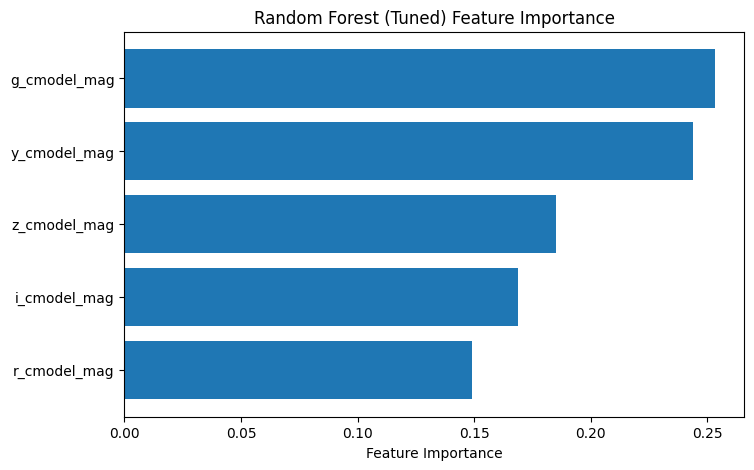

In [22]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Random Forest (Tuned) Feature Importance")
plt.show()

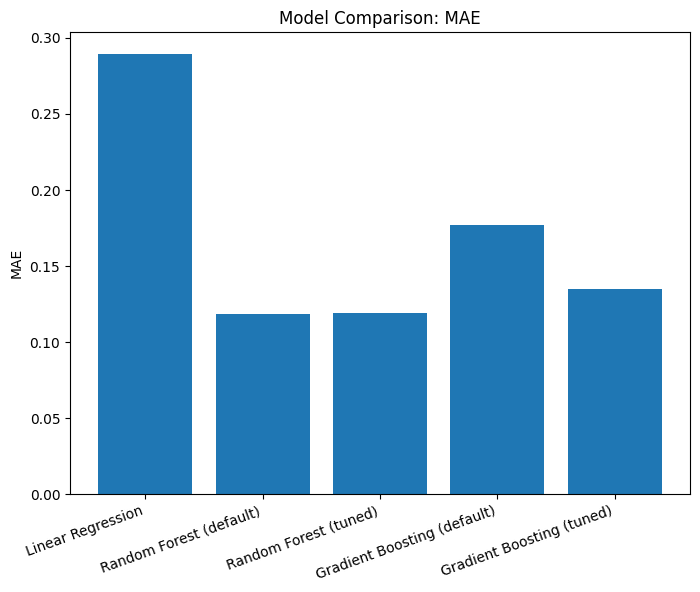

In [23]:
plt.figure(figsize=(8, 6))
plt.bar(results['Model'], results['MAE'])
plt.ylabel("MAE")
plt.title("Model Comparison: MAE")
plt.xticks(rotation=20, ha='right')
plt.show()

In [24]:
best_model = results.loc[results['R2'].idxmax()]
print("Best Model:")
print(best_model)

Best Model:
Model          Random Forest (tuned)
R2                          0.735593
Training R2                 0.936793
MAE                         0.118799
RMSE                        0.293839
Name: 2, dtype: object
